# Driver Style Analysis and Integration

## Objective

The objective of this notebook is to analyze driver-specific tyre management characteristics from historical Formula 1 race data.

A Driver Tyre Management Score is computed for every driver using multiple performance metrics including tyre degradation, average tyre life, lap performance, and race position.

The drivers are then grouped into different driving styles using K-Means clustering. These driver profiles will later be integrated into the machine learning pipeline to create a driver-aware race strategy prediction system.

### Outputs

- Driver Performance Statistics
- Driver Tyre Management Score
- Driver Driving Style Clusters
- Driver Profiles
- Research Figures
- driver_profiles.csv

In [35]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [36]:
# loading the datasets

df = pd.read_csv("../data/processed/master_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11880, 14)


,Driver,Team,LapNumber,Compound,TyreLife,Stint,Position,TrackStatus,LapTimeSeconds,FuelLoadApprox,StintProgress,CompoundEncoded,FreshTyre,TyreAgeSquared
0,VER,Red Bull Racing,1.0,SOFT,4.0,1.0,2.0,1,83.186,0.984848,0.100,0,0,16.0
1,VER,Red Bull Racing,2.0,SOFT,5.0,1.0,2.0,1,79.871,0.969697,0.125,0,0,25.0
2,VER,Red Bull Racing,3.0,SOFT,6.0,1.0,1.0,1,79.364,0.954545,0.150,0,0,36.0
3,VER,Red Bull Racing,4.0,SOFT,7.0,1.0,1.0,1,80.766,0.939394,0.175,0,0,49.0
4,VER,Red Bull Racing,5.0,SOFT,8.0,1.0,1.0,1,80.827,0.924242,0.200,0,0,64.0


In [37]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nColumns\n")
print(df.columns.tolist())

print("\n")

print(df.info())

print("\n")

print(df.describe())

DATASET INFORMATION

Columns

['Driver', 'Team', 'LapNumber', 'Compound', 'TyreLife', 'Stint', 'Position', 'TrackStatus', 'LapTimeSeconds', 'FuelLoadApprox', 'StintProgress', 'CompoundEncoded', 'FreshTyre', 'TyreAgeSquared']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11880 entries, 0 to 11879
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Driver           11880 non-null  object 
 1   Team             11880 non-null  object 
 2   LapNumber        11880 non-null  float64
 3   Compound         11880 non-null  object 
 4   TyreLife         11880 non-null  float64
 5   Stint            11880 non-null  float64
 6   Position         11880 non-null  float64
 7   TrackStatus      11880 non-null  int64  
 8   LapTimeSeconds   11880 non-null  float64
 9   FuelLoadApprox   11880 non-null  float64
 10  StintProgress    11880 non-null  float64
 11  CompoundEncoded  11880 non-null  int64  
 12  FreshTyre      

In [38]:
missing = df.isnull().sum()
print(missing)

Driver             0
Team               0
LapNumber          0
Compound           0
TyreLife           0
Stint              0
Position           0
TrackStatus        0
LapTimeSeconds     0
FuelLoadApprox     0
StintProgress      0
CompoundEncoded    0
FreshTyre          0
TyreAgeSquared     0
dtype: int64


In [39]:
# driver distribution

driver_counts = (
    df["Driver"]
    .value_counts()
    .sort_values(ascending=False)
)

driver_counts

Driver
RUS    632
HAM    630
SAI    630
VER    628
NOR    625
PER    624
GAS    619
MAG    617
BOT    615
ALO    592
LEC    578
STR    567
OCO    566
ZHO    564
ALB    509
HUL    493
TSU    460
PIA    410
RIC    405
SAR    332
MSC    170
DEV    160
LAT    150
COL    114
LAW     98
VET     92
Name: count, dtype: int64

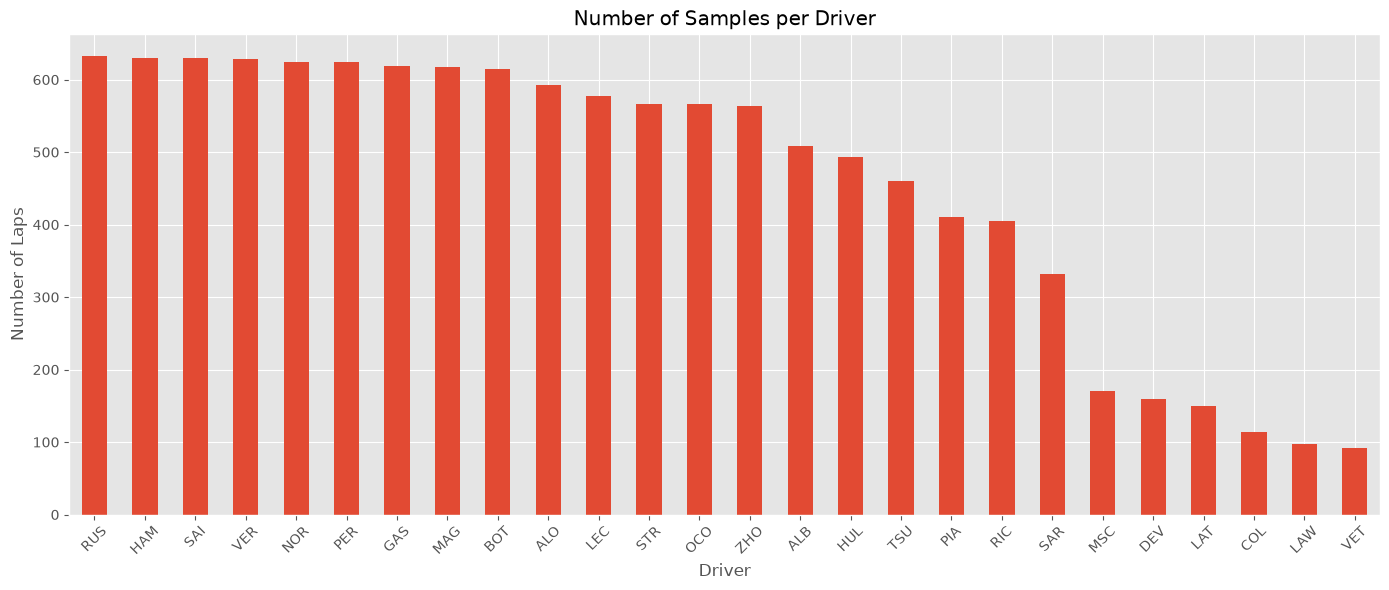

In [40]:
# driver distribution plot

plt.figure(figsize=(14,6))
driver_counts.plot(kind="bar")
plt.title("Number of Samples per Driver")
plt.xlabel("Driver")
plt.ylabel("Number of Laps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# creating the driver stats

driver_stats = (
    df
    .groupby("Driver")
    .agg(
        AverageLapTime=("LapTimeSeconds","mean"),
        AverageTyreLife=("TyreLife","mean"),
        AveragePosition=("Position","mean"),
        AverageStint=("Stint","mean"),
        AverageTrackStatus=("TrackStatus","mean"),
        Samples=("Driver","count")
    )
    .reset_index()
)

driver_stats

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615
3,COL,93.165702,15.807018,11.912281,1.605263,1.0,114
4,DEV,89.314769,12.393750,13.731250,2.118750,1.0,160
5,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619
6,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630
7,HUL,92.569937,12.068966,14.036511,2.241379,1.0,493
8,LAT,93.820253,10.333333,17.313333,2.260000,1.0,150
9,LAW,94.394224,14.479592,12.153061,1.877551,1.0,98


In [42]:
# removing the small sample drivers

driver_stats = driver_stats[
    driver_stats["Samples"] >= 400
]
driver_stats

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615
5,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619
6,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630
7,HUL,92.569937,12.068966,14.036511,2.241379,1.0,493
10,LEC,91.456439,13.951557,4.564014,1.865052,1.0,578
11,MAG,92.839451,12.132901,14.481361,2.213938,1.0,617
13,NOR,92.001309,12.598400,7.985600,2.126400,1.0,625
14,OCO,91.700959,12.130742,11.240283,2.008834,1.0,566


In [43]:
# creating the driver degradation

driver_scores = []

for driver in driver_stats["Driver"]:

    driver_df = df[df["Driver"] == driver].copy()

    # -------------------------
    # Degradation Rate
    # -------------------------
    if driver_df["TyreLife"].nunique() > 1:
        degradation_rate = np.polyfit(
            driver_df["TyreLife"],
            driver_df["LapTimeSeconds"],
            1
        )[0]
    else:
        degradation_rate = 0

    # -------------------------
    # Driver Consistency
    # -------------------------
    consistency = driver_df["LapTimeSeconds"].std()

    # -------------------------
    # Tyre Preservation Index
    # -------------------------
    tyre_preservation = (
        driver_df["TyreLife"].mean() /
        driver_df["Stint"].mean()
    )

    # -------------------------
    # End-of-Stint Performance
    # -------------------------
    threshold = driver_df["TyreLife"].quantile(0.70)

    end_stint_laps = driver_df[
        driver_df["TyreLife"] >= threshold
    ]

    end_stint_performance = end_stint_laps[
        "LapTimeSeconds"
    ].mean()

    driver_scores.append({

        "Driver": driver,

        "DegradationRate": degradation_rate,

        "ConsistencyScore": consistency,

        "TyrePreservationIndex": tyre_preservation,

        "EndStintPerformance": end_stint_performance

    })

driver_scores = pd.DataFrame(driver_scores)

driver_scores.head()

,Driver,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance
0,ALB,-0.348687,8.789415,5.292505,88.987437
1,ALO,-0.157507,8.375343,6.273569,90.288026
2,BOT,-0.108194,9.045381,7.487701,91.604741
3,GAS,-0.073890,9.615833,5.556561,91.679517
4,HAM,-0.076499,9.187140,6.453137,90.742358


In [44]:
# merging the stats

driver_profiles = driver_stats.merge(
    driver_scores,
    on="Driver",
    how="left"
)

driver_profiles.head()

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509,-0.348687,8.789415,5.292505,88.987437
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592,-0.157507,8.375343,6.273569,90.288026
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615,-0.108194,9.045381,7.487701,91.604741
3,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619,-0.073890,9.615833,5.556561,91.679517
4,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630,-0.076499,9.187140,6.453137,90.742358


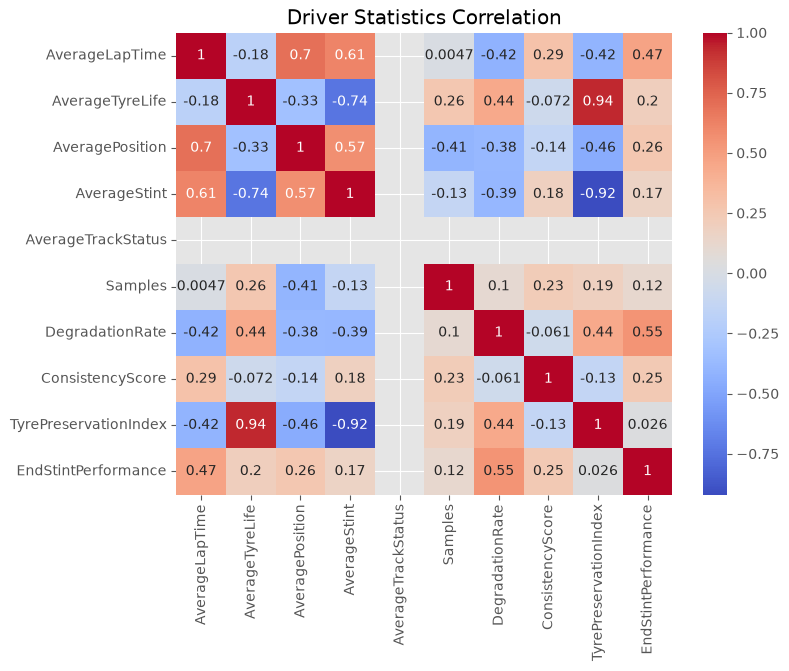

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(
    driver_profiles.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Driver Statistics Correlation")
plt.show()

In [46]:
 driver_profiles

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509,-0.348687,8.789415,5.292505,88.987437
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592,-0.157507,8.375343,6.273569,90.288026
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615,-0.108194,9.045381,7.487701,91.604741
3,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619,-0.073890,9.615833,5.556561,91.679517
4,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630,-0.076499,9.187140,6.453137,90.742358
5,HUL,92.569937,12.068966,14.036511,2.241379,1.0,493,-0.074035,9.571798,5.384615,92.030939
6,LEC,91.456439,13.951557,4.564014,1.865052,1.0,578,-0.155010,9.391440,7.480519,90.366995
7,MAG,92.839451,12.132901,14.481361,2.213938,1.0,617,-0.164163,9.306403,5.480234,92.028551
8,NOR,92.001309,12.598400,7.985600,2.126400,1.0,625,-0.127047,9.650178,5.924755,91.043725
9,OCO,91.700959,12.130742,11.240283,2.008834,1.0,566,-0.235654,8.996863,6.038698,90.196371


In [ ]:
# select features

from sklearn.preprocessing import MinMaxScaler

features = driver_profiles[
[
    "AverageLapTime",
    "AverageTyreLife",
    "AveragePosition",
    "AverageStint",
    "DegradationRate",
    "ConsistencyScore",
    "TyrePreservationIndex",
    "EndStintPerformance"
]
].copy()

# Lower lap time = better
features["AverageLapTime"] *= -1

# Lower position = better
features["AveragePosition"] *= -1

# Lower degradation = better
features["DegradationRate"] *= -1

# Lower consistency std = better
features["ConsistencyScore"] *= -1

# Lower end-stint lap time = better
features["EndStintPerformance"] *= -1


In [48]:
driver_profiles.columns

Index(['Driver', 'AverageLapTime', 'AverageTyreLife', 'AveragePosition',
       'AverageStint', 'AverageTrackStatus', 'Samples', 'DegradationRate',
       'ConsistencyScore', 'TyrePreservationIndex', 'EndStintPerformance'],
      dtype='object')

In [49]:
# normalisation

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[0.44995331, 0.        , 0.05991501, 0.75269245, 1.        ,
        0.7280808 , 0.09287048, 1.        ],
       [0.5175564 , 0.40758286, 0.45126544, 0.3867473 , 0.53647581,
        1.        , 0.49827946, 0.61516685],
       [0.19088086, 1.        , 0.06775955, 0.15652647, 0.41691582,
        0.55998891, 1.        , 0.22556214],
       [0.22973139, 0.17716813, 0.16353634, 0.73434433, 0.33374417,
        0.18537634, 0.20198756, 0.20343646],
       [0.52130887, 0.62048464, 0.69625109, 0.49571686, 0.34006881,
        0.46689649, 0.57248306, 0.480734  ]])

In [50]:
# elbow method

from sklearn.cluster import KMeans

inertia = []

for k in range(2,8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

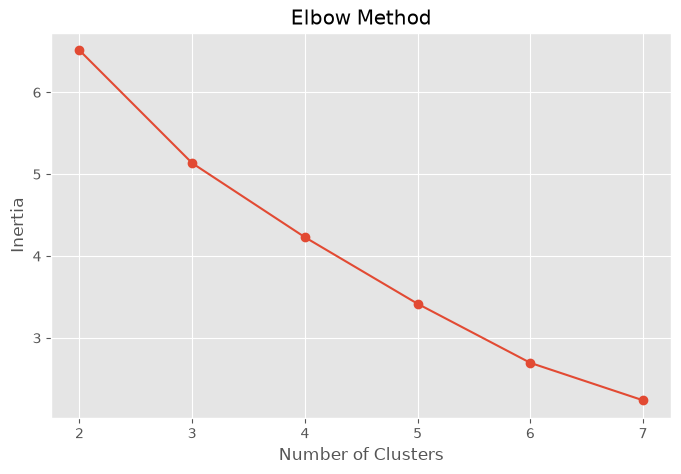

In [51]:
# plotting the elbow

plt.figure(figsize=(8,5))
plt.plot(
    range(2,8),
    inertia,
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [69]:
#the silhouette score

from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, driver_profiles["DrivingStyleCluster"])

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.267


In [70]:
# training the final k-means model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)
driver_profiles["DrivingStyleCluster"] = kmeans.fit_predict(
    scaled_features
)
driver_profiles.head()

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance,DrivingStyleCluster
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509,-0.348687,8.789415,5.292505,88.987437,0
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592,-0.157507,8.375343,6.273569,90.288026,0
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615,-0.108194,9.045381,7.487701,91.604741,2
3,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619,-0.073890,9.615833,5.556561,91.679517,1
4,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630,-0.076499,9.187140,6.453137,90.742358,2


In [74]:
cluster_names = {
    0: "Conservative Tyre Manager",
    1: "Aggressive Driver",
    2: "Performance Driver"
}

driver_profiles["DrivingStyle"] = (
    driver_profiles["DrivingStyleCluster"]
    .map(cluster_names)
)

driver_profiles.head()

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance,DrivingStyleCluster,DrivingStyle
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509,-0.348687,8.789415,5.292505,88.987437,0,Conservative Tyre Manager
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592,-0.157507,8.375343,6.273569,90.288026,0,Conservative Tyre Manager
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615,-0.108194,9.045381,7.487701,91.604741,2,Performance Driver
3,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619,-0.073890,9.615833,5.556561,91.679517,1,Aggressive Driver
4,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630,-0.076499,9.187140,6.453137,90.742358,2,Performance Driver


In [75]:
driver_profiles["DrivingStyleCluster"] = kmeans.labels_

cluster_summary = (
    driver_profiles
    .groupby("DrivingStyleCluster")
    .mean(numeric_only=True)
)

display(cluster_summary)

print("\nDrivers in each cluster:\n")

for cluster in sorted(driver_profiles["DrivingStyleCluster"].unique()):

    cluster_df = driver_profiles[
        driver_profiles["DrivingStyleCluster"] == cluster
    ]

    print("=" * 60)
    print(f"Cluster {cluster}")
    print("=" * 60)

    print("Drivers:")
    print(", ".join(cluster_df["Driver"]))

    print("\nNumber of drivers:", len(cluster_df))

    print("\nAverage metrics:")
    display(cluster_df.mean(numeric_only=True).round(3))

,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance
DrivingStyleCluster,,,,,,,,,,
0,91.790516,11.898671,10.290907,2.102681,1.0,551.800000,-0.231022,8.941233,5.677472,89.971183
1,92.511770,12.411199,12.762403,2.140908,1.0,555.714286,-0.125013,9.365936,5.805246,91.612278
2,91.413808,13.335843,6.423537,1.949641,1.0,587.857143,-0.036597,9.104560,6.851890,91.034477



Drivers in each cluster:

Cluster 0
Drivers:
ALB, ALO, OCO, RUS, TSU

Number of drivers: 5

Average metrics:


AverageLapTime            91.791
AverageTyreLife           11.899
AveragePosition           10.291
AverageStint               2.103
AverageTrackStatus         1.000
Samples                  551.800
DegradationRate           -0.231
ConsistencyScore           8.941
TyrePreservationIndex      5.677
EndStintPerformance       89.971
DrivingStyleCluster        0.000
dtype: float64

Cluster 1
Drivers:
GAS, HUL, MAG, NOR, RIC, STR, ZHO

Number of drivers: 7

Average metrics:


AverageLapTime            92.512
AverageTyreLife           12.411
AveragePosition           12.762
AverageStint               2.141
AverageTrackStatus         1.000
Samples                  555.714
DegradationRate           -0.125
ConsistencyScore           9.366
TyrePreservationIndex      5.805
EndStintPerformance       91.612
DrivingStyleCluster        1.000
dtype: float64

Cluster 2
Drivers:
BOT, HAM, LEC, PER, PIA, SAI, VER

Number of drivers: 7

Average metrics:


AverageLapTime            91.414
AverageTyreLife           13.336
AveragePosition            6.424
AverageStint               1.950
AverageTrackStatus         1.000
Samples                  587.857
DegradationRate           -0.037
ConsistencyScore           9.105
TyrePreservationIndex      6.852
EndStintPerformance       91.034
DrivingStyleCluster        2.000
dtype: float64

In [82]:
from sklearn.decomposition import PCA

# Reduce features to 2 dimensions
pca = PCA(n_components=2, random_state=42)

pca_result = pca.fit_transform(scaled_features)

# Create dataframe for plotting
pca_df = driver_profiles.copy()

pca_df["PC1"] = pca_result[:, 0]
pca_df["PC2"] = pca_result[:, 1]

pca_df.head()

,Driver,AverageLapTime,AverageTyreLife,AveragePosition,AverageStint,AverageTrackStatus,Samples,DegradationRate,ConsistencyScore,TyrePreservationIndex,EndStintPerformance,DrivingStyleCluster,DrivingStyle,PC1,PC2
0,ALB,91.837320,11.375246,13.768173,2.149312,1.0,509,-0.348687,8.789415,5.292505,88.987437,0,Conservative Tyre Manager,0.700735,0.685958
1,ALO,91.617350,12.589527,9.109797,2.006757,1.0,592,-0.157507,8.375343,6.273569,90.288026,0,Conservative Tyre Manager,-0.156405,0.265864
2,BOT,92.680304,14.354472,13.674797,1.917073,1.0,615,-0.108194,9.045381,7.487701,91.604741,2,Performance Driver,-0.458692,-0.658118
3,GAS,92.553890,11.903069,12.534733,2.142165,1.0,619,-0.073890,9.615833,5.556561,91.679517,1,Aggressive Driver,0.477171,-0.232323
4,HAM,91.605140,13.223810,6.193651,2.049206,1.0,630,-0.076499,9.187140,6.453137,90.742358,2,Performance Driver,-0.348209,0.064671


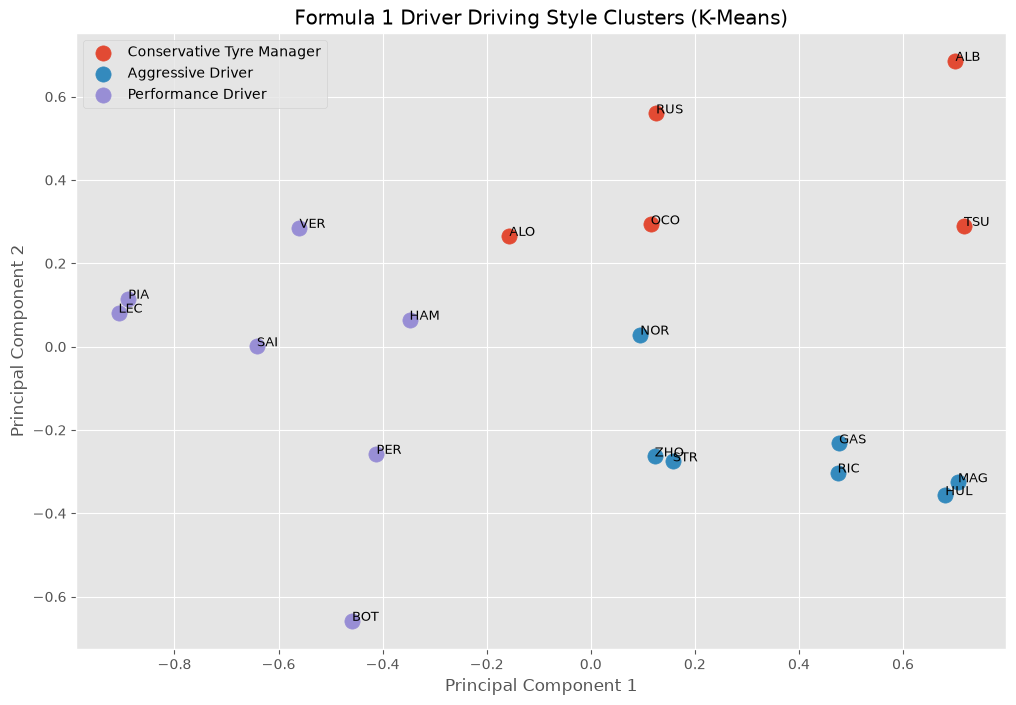

In [83]:
# plotting the driver clusters

plt.figure(figsize=(12,8))

for cluster in sorted(driver_profiles["DrivingStyleCluster"].unique()):

    subset = pca_df[
    pca_df["DrivingStyleCluster"] == cluster
]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=120,
        label=cluster_names[cluster]
    )

    for _, row in subset.iterrows():

        plt.text(
            row["PC1"],
            row["PC2"],
            row["Driver"],
            fontsize=9
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Formula 1 Driver Driving Style Clusters (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

In [84]:
import joblib

joblib.dump(kmeans, "driving_style_kmeans.pkl")
joblib.dump(scaler, "driving_style_scaler.pkl")

driver_profiles.to_csv(
    "driver_profiles_with_clusters.csv",
    index=False
)

print("Notebook 8 completed successfully!")

Notebook 8 completed successfully!


In [85]:
driver_profiles[[
    "Driver",
    "DrivingStyleCluster",
    "DrivingStyle"
]]

,Driver,DrivingStyleCluster,DrivingStyle
0,ALB,0,Conservative Tyre Manager
1,ALO,0,Conservative Tyre Manager
2,BOT,2,Performance Driver
3,GAS,1,Aggressive Driver
4,HAM,2,Performance Driver
5,HUL,1,Aggressive Driver
6,LEC,2,Performance Driver
7,MAG,1,Aggressive Driver
8,NOR,1,Aggressive Driver
9,OCO,0,Conservative Tyre Manager
